# Baseline training — thin orchestration

All modeling logic lives in `src/`; this notebook only loads a config,
instantiates `Trainer`, runs it, and plots the results. The default config
(`configs/train.yaml`) trains a single model — ElasticNet on the full
254-feature set — which is the best-performing configuration found during
the original exploration (see README for the full 6-model x 3-feature-set
comparison). Override `training.models` / `feature_selection.mode` to
reproduce the rest of that sweep, e.g. from a shell:

```
python -m src.train training.models='[LinearRegression,KNN,RandomForest,Ridge,Lasso,ElasticNet]'
```

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from omegaconf import OmegaConf

from src.train import Trainer

cfg = OmegaConf.load("../configs/train.yaml")

# Paths in configs/train.yaml are relative to the repo root (how
# `python -m src.train` is normally run); this notebook's kernel CWD is
# its own directory, so rebase them here.
cfg.data.train_path = f"../{cfg.data.train_path}"
cfg.data.test_path = f"../{cfg.data.test_path}"
cfg.output.models_dir = f"../{cfg.output.models_dir}"
cfg.output.runs_dir = f"../{cfg.output.runs_dir}"
cfg.output.metrics_csv = f"../{cfg.output.metrics_csv}"

trainer = Trainer(cfg)

In [3]:
trainer.prepare_data()
metrics = trainer.fit()

2026-08-10 10:53:59,855 INFO src.train: Prepared data: mode=full, n_features=254


2026-08-10 10:53:59,857 INFO src.train: Running grid search for ElasticNet


2026-08-10 10:54:35,392 INFO src.train: ElasticNet: best_cv_score=0.8305 test_r2=0.8985 rmse_dollars=22839.53


## Results

`rmse_dollars` is computed after undoing the target's `log1p` transform, so
it reads directly as an average prediction error in dollars — the metric
that matters for interpreting model quality, as opposed to `test_r2`, which
is computed on the log scale.

In [4]:
import pandas as pd

results = pd.DataFrame([m.__dict__ for m in metrics]).sort_values("rmse_dollars")
results[["model_name", "feature_selection", "best_cv_score", "test_r2", "rmse_dollars", "grid_search_seconds"]]

,model_name,feature_selection,best_cv_score,test_r2,rmse_dollars,grid_search_seconds
0,ElasticNet,full,0.830455,0.898511,22839.530111,35.467979


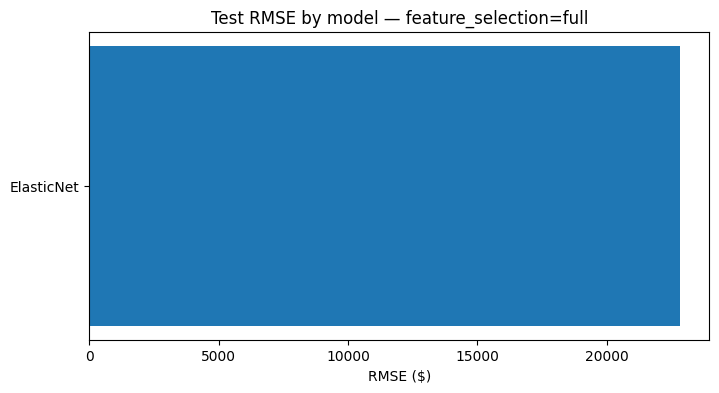

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.barh(results["model_name"], results["rmse_dollars"])
plt.xlabel("RMSE ($)")
plt.title(f"Test RMSE by model — feature_selection={cfg.feature_selection.mode}")
plt.gca().invert_yaxis()
plt.show()

The trained model and preprocessor for the best run (lowest RMSE) are
persisted to `models/best_model.joblib` and `models/preprocessor.joblib`,
and every run's metrics are appended to `outputs/metrics.csv` — so repeated
runs with different config overrides build up a comparable history instead
of overwriting each other.